# Replicating Avellaneda & Stoikov (2008): *High-frequency trading in a limit order book*

Quantitative Finance 8(3), 217–224. The simulator lives in the `mmsim/` package and the unit tests in `tests/` (`pytest -q`); this notebook only runs the experiments, draws the figures and interprets the results. Derivations are in the appendix at the end.

## TL;DR

- **Paper numbers checked against the original.** The Tables 1–3 numbers used for comparison were checked one by one against the PDF of the published journal version (hosted by NYU), instead of relying on second-hand quotations.
- **Consistent with the paper.** A dynamic program on the (inventory, time step) grid computes the mean, standard deviation and kurtosis of terminal PnL and the terminal inventory distribution of both strategies **exactly**, without simulation. All 24 numbers in the paper's Tables 1–3 lie within 1.9 standard errors of the exact values (χ² = 19.4, 24 degrees of freedom), fully consistent with "the paper and this implementation are the same model, and the differences come only from the sampling noise of the paper's 1000 paths" (Section 6).
- **Three-way cross-validation.** The dynamic program agrees with brute-force enumeration of all paths on a small model to 1e−9, with the closed form for the symmetric strategy to 1e−10, and with a 40000-path Monte Carlo at the paper's parameters.
- **Correcting an earlier conclusion.** I previously thought the paper's symmetric PnL std (12.7 at γ=0.1) was about 2.5 standard errors below the true value 13.46. That came from estimating the standard error as if PnL were normal; the symmetric strategy's PnL has kurtosis ≈ 5.4, so the sampling error of the sample standard deviation is about 1.5 times the normal-case value, and after the correction the gap is only about 1.7 standard errors.
- **The CARA certainty equivalent cannot be estimated by Monte Carlo.** At γ=0.1 the exact CE of the symmetric strategy is 39.8, yet even with 1 million paths Monte Carlo keeps bouncing between 45 and 55, always clearly too high: expected utility is dominated by a handful of paths on which inventory runs away (Section 6.4). The exact CE of the A-S strategy is 62.8.
- **Results depend on dt.** As dt → 0 the symmetric strategy's PnL standard deviation rises from 13.5 to about 15.3, because per-step Bernoulli fills understate the variance of Poisson fills (Section 7).
- The figure below shows the core trade-off: at the same spread, skewing quotes by inventory (A-S) gives up a little mean in exchange for a large reduction in variance, and γ controls how much is traded.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from mmsim import (Params, AvellanedaStoikov, Symmetric, simulate, draw_randomness,
                   symmetric_moments, symmetric_moments_continuous, summarize, paired_diff,
                   std_se, mean_se, average_as_spread, exact_moments, sampling_se, cara_ce)

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})
pd.set_option("display.width", 200)

P = Params()               # paper parameters
N_PATHS, SEED = 1000, 2008
GAMMAS = [0.1, 0.01, 1.0]  # Tables 1, 2, 3 of the published version

# Published version, Quantitative Finance 8(3) 2008, Tables 1-3 (verified against the journal PDF hosted by NYU:
# https://math.nyu.edu/inmemoriam/avellaneda//HighFrequencyTrading.pdf): spread, profit, std(profit), final q, std(final q)
PAPER = {
    (0.1,  "inventory"): (1.49, 65.0,  6.6, 0.08, 2.9),
    (0.1,  "symmetric"): (1.49, 68.4, 12.7, 0.26, 8.4),
    (0.01, "inventory"): (1.35, 68.6,  8.7, 0.12, 5.1),
    (0.01, "symmetric"): (1.35, 68.8, 12.8, 0.09, 8.7),
    (1.0,  "inventory"): (3.02, 31.4,  5.0, 0.02, 1.7),
    (1.0,  "symmetric"): (3.02, 44.0, 11.0, 0.00, 5.1),
}

def strategies(gamma, p=P):
    return {"inventory": AvellanedaStoikov(gamma), "symmetric": Symmetric.matching(gamma, p)}

# Main experiment: both strategies see the same randomness (common random numbers)
results = {}
for g in GAMMAS:
    rnd = draw_randomness(P, N_PATHS, SEED)
    for name, strat in strategies(g).items():
        results[(g, name)] = simulate(strat, P, N_PATHS, randomness=rnd, log_trades=True)

# Exact values by dynamic programming (Section 6), and the paper's numbers measured in 1000-path SEs
EXACT = {(g, name): exact_moments(strat, P, gamma_ce=g) for g in GAMMAS for name, strat in strategies(g).items()}

rows = []
for (g, name), ex in EXACT.items():
    pp, se = PAPER[(g, name)], sampling_se(ex, N_PATHS)
    rows.append({"gamma": g, "strategy": name,
                 "profit (paper)": pp[1], "profit (exact)": ex["mean_pnl"], "z profit": (pp[1] - ex["mean_pnl"]) / se["mean_pnl"],
                 "std (paper)": pp[2], "std (exact)": ex["std_pnl"], "z std": (pp[2] - ex["std_pnl"]) / se["std_pnl"],
                 "std q (paper)": pp[4], "std q (exact)": ex["std_q"], "z std q": (pp[4] - ex["std_q"]) / se["std_q"]})
pd.DataFrame(rows).set_index(["gamma", "strategy"]).round(2)

profit (paper)  profit (exact)  z profit  std (paper)  std (exact)  z std  std q (paper)  std q (exact)  z std q
gamma strategy                                                                                                                   
0.10  inventory            65.0           64.89      0.52          6.6         6.54   0.39            2.9           2.93    -0.41
      symmetric            68.4           68.22      0.42         12.7        13.46  -1.69            8.4           8.40     0.00
0.01  inventory            68.6           68.40      0.71          8.7         8.96  -1.13            5.1           5.21    -0.97
      symmetric            68.8           68.67      0.31         12.8        13.68  -1.89            8.7           8.71    -0.06
1.00  inventory            31.4           31.45     -0.36          5.0         4.84   1.47            1.7           1.64     1.61
      symmetric            44.0           43.69      0.93         11.0        10.73   0.92            5.1           5.17    -0.61

"exact" is the exact value from the dynamic program of Section 6 (the true value in this discrete model, free of any sampling error). **z** is the number of "1000-path sampling standard errors" by which the paper's number deviates from the exact value; the standard errors are likewise computed from the exact variance and kurtosis. The paper used only 1000 paths, so |z| ≲ 2 is ordinary sampling noise.

The figure below sweeps γ continuously (4000 paths per γ). The left panel shows the two strategies' frontiers in the mean–standard deviation plane; the right panel shows how much of the mean the inventory strategy retains relative to the symmetric one, and how much of the risk is left.

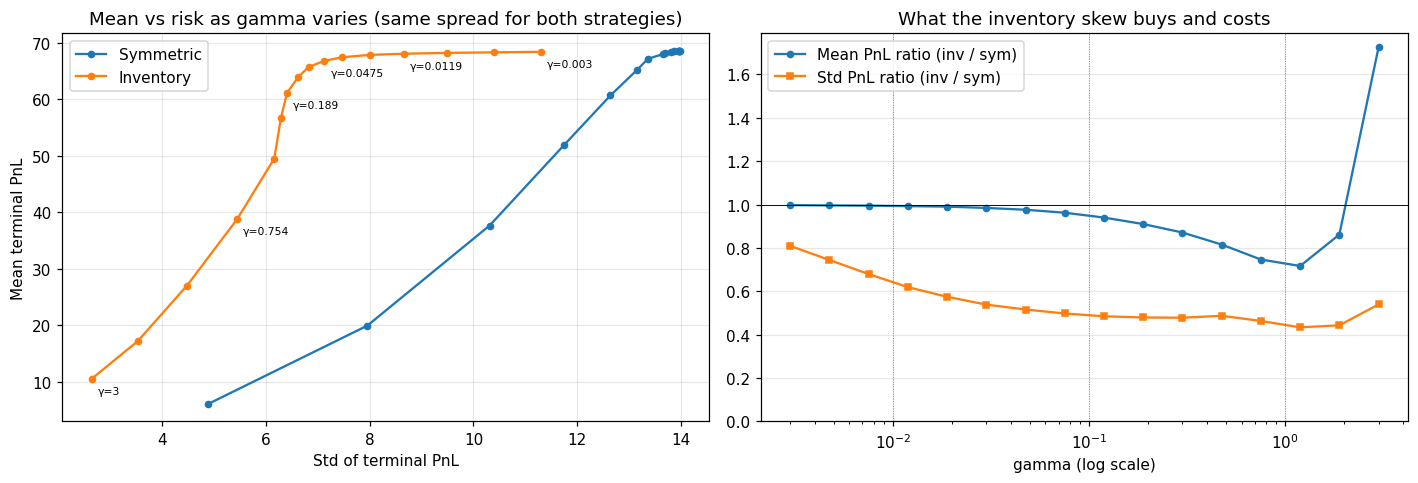

In [2]:
gamma_grid = np.geomspace(0.003, 3, 16)
sweep = []
for g in gamma_grid:
    rnd = draw_randomness(P, 4000, seed=1)
    row = {"gamma": g}
    for name, strat in strategies(g).items():
        r = simulate(strat, P, 4000, randomness=rnd)
        row[f"mean_{name}"], row[f"std_{name}"] = r.pnl.mean(), r.pnl.std()
    sweep.append(row)
sweep = pd.DataFrame(sweep)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))
for name, c in [("symmetric", "tab:blue"), ("inventory", "tab:orange")]:
    ax1.plot(sweep[f"std_{name}"], sweep[f"mean_{name}"], "o-", color=c, ms=4, label=name.capitalize())
for _, row in sweep.iloc[::3].iterrows():
    ax1.annotate(f"γ={row.gamma:.3g}", (row.std_inventory, row.mean_inventory), fontsize=7,
                 xytext=(4, -10), textcoords="offset points")
ax1.set_xlabel("Std of terminal PnL"); ax1.set_ylabel("Mean terminal PnL")
ax1.set_title("Mean vs risk as gamma varies (same spread for both strategies)"); ax1.legend()

ax2.semilogx(sweep.gamma, sweep.mean_inventory / sweep.mean_symmetric, "o-", ms=4, label="Mean PnL ratio (inv / sym)")
ax2.semilogx(sweep.gamma, sweep.std_inventory / sweep.std_symmetric, "s-", ms=4, label="Std PnL ratio (inv / sym)")
for g in GAMMAS:
    ax2.axvline(g, color="grey", lw=0.6, ls=":")
ax2.axhline(1, color="k", lw=0.6); ax2.set_xlabel("gamma (log scale)"); ax2.set_ylim(bottom=0)
ax2.set_title("What the inventory skew buys and costs"); ax2.legend()
plt.tight_layout(); plt.show()

**How to read it:** in the left panel, points on the two curves with the same γ use the same spread, so the horizontal distance between them is the risk reduction bought by the inventory skew. The right panel shows that over the range γ ≈ 0.01–1 that the paper focuses on, the inventory strategy retains about 70%–100% of the mean while its PnL standard deviation drops to about 45%–65%.

Beyond γ ≈ 2 the mean ratio in the right panel rises quickly and exceeds 1. This is not A-S becoming more profitable but the benchmark breaking down: the symmetric strategy uses the **average** spread over the whole horizon, and for large γ the A-S spread is extremely wide at the start and narrow at the end, so the average is too wide for the symmetric strategy and it hardly trades. The "same average spread" benchmark is therefore only meaningful for small and moderate γ.

## 1. What the paper does

A market maker continuously posts bids and asks in a limit order book and faces two risks: **inventory risk** from random moves of the mid price, and **execution risk** from not knowing when its orders will be filled. The paper studies only the inventory effect and explicitly leaves out information asymmetry (adverse selection).

**The three ingredients of the model:**

- **The mid price** is an arithmetic Brownian motion $dS = \sigma\,dW$ with no drift, i.e. the market maker has no directional view.
- **The objective** is CARA utility of terminal wealth, $\mathbb{E}[-e^{-\gamma(X_T + q_T S_T)}]$, with inventory valued at the mid at T at no cost.
- **The fill intensity** is $\lambda(\delta) = A e^{-k\delta}$. It is derived from three empirical regularities: a constant arrival rate of market orders, power-law order sizes, and a price impact of the form $\ln Q$. A represents how active the order flow is, and k the depth of the book.

**Approximately optimal quotes** (derived in the appendix): a total spread that does not depend on inventory, centred on the reservation price.

$$r = s - q\gamma\sigma^2(T-t),\qquad \delta^a + \delta^b = \gamma\sigma^2(T-t) + \tfrac{2}{\gamma}\ln\left(1+\tfrac{\gamma}{k}\right)$$

**Numerical experiment:** at each step the market maker first quotes based on the current state; the ask fills with probability $\lambda(\delta^a)dt$ and the bid with probability $\lambda(\delta^b)dt$; then the mid moves by ±σ√dt. The benchmark is the **symmetric** strategy: it uses the inventory strategy's spread **averaged** over the whole horizon, centred on the mid, and ignores inventory.

> **Version note.** Two versions of this paper circulate online, and their tables differ:
>
> - **Published version** (*Quantitative Finance* 2008): the journal-typeset PDF is on the NYU mathematics department's memorial page (math.nyu.edu/inmemoriam/avellaneda/HighFrequencyTrading.pdf). Tables 1–3 use γ = 0.1 / 0.01 / 1, and the text states explicitly that the symmetric strategy uses the inventory strategy's **average** spread (1.49 at γ = 0.1). The `PAPER` numbers in this notebook were checked one by one against this PDF.
> - **Preprint** (2006, Stoikov's Cornell homepage): the tables use γ = 0.1 / 0.01 / 0.5, the "Spread" column reports only $\frac{2}{\gamma}\ln(1+\frac{\gamma}{k})$ (1.29 at γ = 0.1), and the numbers differ too (e.g. 62.94 / 5.89 for the inventory strategy at γ = 0.1). Some articles online quote the preprint's numbers as "the tables of the 2008 paper", so the two need to be kept apart. Appendix B uses the exact solution to show that the preprint's tables do not match the model it describes.
>
> A small detail: PDF text extraction drops minus signs, so the signs of a few numbers in the published version's "Final q" column cannot be confirmed with complete certainty. This does not affect the test in Section 6.3: the exact value of $\mathbb{E}[q_T]$ is 0, so flipping a sign only flips the sign of z, not |z| or χ².

## 2. Code structure

| Module | Contents |
|---|---|
| `mmsim/params.py` | `Params` dataclass; the defaults are the paper's parameters |
| `mmsim/strategies.py` | `AvellanedaStoikov(gamma)`, `Symmetric(spread)`; a new strategy only needs to implement `quote(s, q, i, p) -> (centre, bid, ask)` |
| `mmsim/simulator.py` | Vectorised simulator: common random numbers, PnL decomposition, per-fill trade log, discretisation diagnostics |
| `mmsim/analytics.py` | Exact solutions: closed-form moments of the symmetric strategy (discrete model and continuous-time limit); `exact_moments` runs a dynamic program for any strategy that depends only on (q, t) and gives the first four moments of PnL, the CARA certainty equivalent and the terminal inventory distribution exactly; `sampling_se` derives Monte Carlo standard errors from the exact moments |
| `mmsim/stats.py` | Standard errors, paired differences, CARA certainty equivalent |
| `tests/` | 31 unit tests: PnL decomposition identity, trade-log consistency, common random numbers, comparison with the closed form; three-way checks of the dynamic program against brute-force enumeration of all paths, the closed form and Monte Carlo |

At every step the simulator splits PnL into two parts whose sum is **exactly** the total PnL (checked path by path in the tests):

$$\text{PnL} = \underbrace{\textstyle\sum_{\text{fills}} \text{edge vs mid}}_{\text{spread capture}} + \underbrace{\textstyle\sum_i q_{i+1}\,\Delta S_i}_{\text{inventory PnL}}$$

## 3. What the quoting strategy looks like

### 3.1 Reproducing Figure 1: a single path

γ = 0.1. The seed was chosen to give a path on which inventory swings back and forth visibly, which makes the mechanism easy to see; other seeds behave the same way.

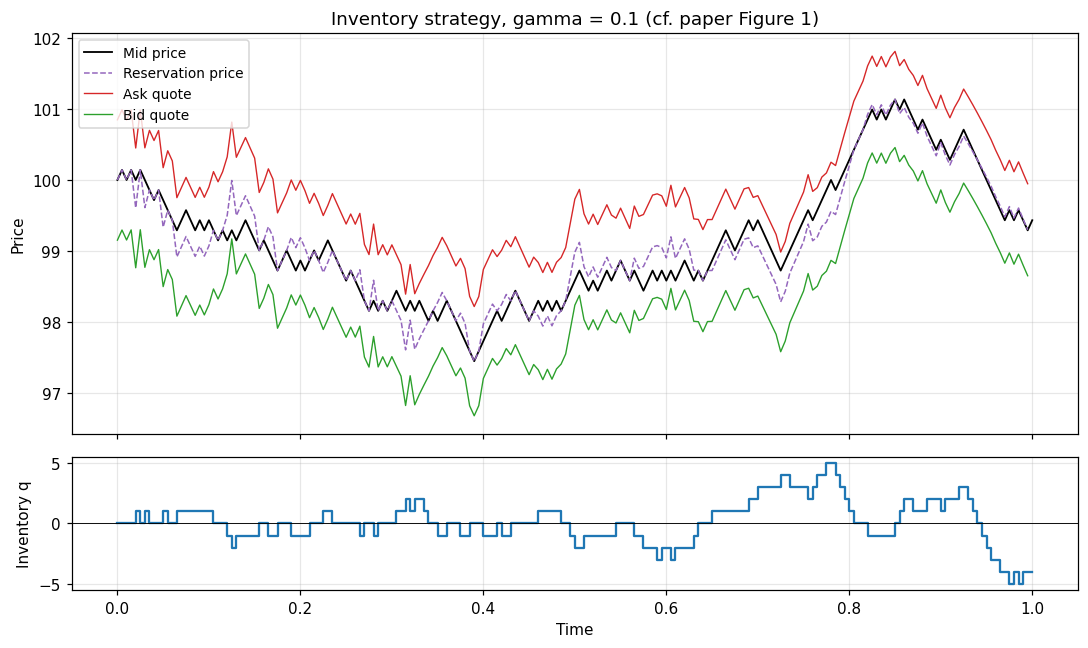

In [3]:
one = simulate(AvellanedaStoikov(0.1), P, n_paths=1, seed=7, record=True)
Pth, t = one.paths, one.t

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True, gridspec_kw={"height_ratios": [3, 1]})
ax1.plot(t, Pth["s"][:, 0], color="k", lw=1.2, label="Mid price")
ax1.plot(t, Pth["r"][:, 0], color="tab:purple", lw=1, ls="--", label="Reservation price")
ax1.plot(t, Pth["ask"][:, 0], color="tab:red", lw=0.9, label="Ask quote")
ax1.plot(t, Pth["bid"][:, 0], color="tab:green", lw=0.9, label="Bid quote")
ax1.set_ylabel("Price"); ax1.legend(loc="upper left", fontsize=9)
ax1.set_title("Inventory strategy, gamma = 0.1 (cf. paper Figure 1)")
ax2.step(t, Pth["q"][:, 0], where="post", color="tab:blue")
ax2.axhline(0, color="k", lw=0.6); ax2.set_ylabel("Inventory q"); ax2.set_xlabel("Time")
plt.tight_layout(); plt.show()

### 3.2 The whole quoting policy: δ as a function of inventory and time

A single path shows only one slice of the strategy. The figure below plots, for γ = 0.1 and several values of the remaining time, the distances of the ask and the bid from the mid as a function of inventory q.

- The two lines have opposite slopes: when long, the ask moves closer and the bid moves away.
- The slope $\gamma\sigma^2(T-t)$ decays over time and is almost flat near T, where the strategy reduces to symmetric quoting.
- δ < 0 means the quote has crossed the mid (e.g. with a large long position the ask sits below the mid); the fill probability $A e^{-k\delta}dt$ can then exceed 1, and the simulator clips it (Section 7 reports how often this happens).

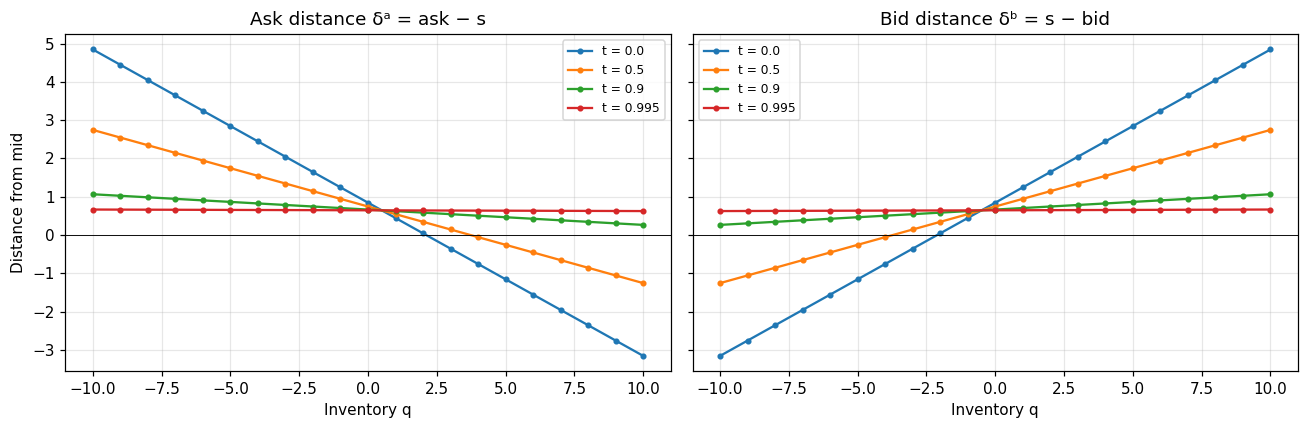

In [4]:
qs = np.arange(-10, 11)
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
strat = AvellanedaStoikov(0.1)
for tt, c in zip([0.0, 0.5, 0.9, 0.995], ["tab:blue", "tab:orange", "tab:green", "tab:red"]):
    i = int(round(tt / P.dt))
    r, bid, ask = strat.quote(np.full(qs.size, P.s0), qs.astype(float), i, P)
    axes[0].plot(qs, ask - P.s0, "o-", ms=3, color=c, label=f"t = {tt}")
    axes[1].plot(qs, P.s0 - bid, "o-", ms=3, color=c, label=f"t = {tt}")
for ax, title in zip(axes, ["Ask distance δᵃ = ask − s", "Bid distance δᵇ = s − bid"]):
    ax.axhline(0, color="k", lw=0.6); ax.set_xlabel("Inventory q"); ax.set_title(title); ax.legend(fontsize=8)
axes[0].set_ylabel("Distance from mid")
plt.tight_layout(); plt.show()

## 4. Tables 1–3: full comparison, standard errors and paired comparison

### 4.1 One experiment of the same size as the paper's

This uses 1000 paths and seed = 2008, the same sample size as the paper. "SE" is the Monte Carlo standard error: the SE of the mean is std/√N, and the SE of the standard deviation uses the normal approximation std/√(2(N−1)). Differences between a single 1000-path experiment and the paper should be judged against the exact values in the first table of this notebook (computed by the dynamic program of Section 6), not directly against this table. For example, for the inventory strategy at γ = 0.01 this seed gives std 9.5, whereas the exact value is 8.96, and the paper's 8.7 is only about one standard error away from it.

In [5]:
full = []
for (g, name), res in results.items():
    s = summarize(res, g)
    pp = PAPER[(g, name)]
    full.append({"gamma": g, "strategy": name,
                 "spread": average_as_spread(g, P) if name == "symmetric" else np.nan,
                 "profit": s["profit"], "profit SE": s["profit SE"], "paper profit": pp[1],
                 "std": s["std profit"], "std SE": s["std profit SE"], "paper std": pp[2],
                 "final q": s["final q"], "final q SE": s["final q SE"], "paper q": pp[3],
                 "std q": s["std q"], "paper std q": pp[4],
                 "trades": s["trades"], "CE (exact, DP)": EXACT[(g, name)]["ce"], "CE (mean-var, MC)": s["CE (mean-var)"]})
pd.DataFrame(full).set_index(["gamma", "strategy"]).round(2)

spread  profit  profit SE  paper profit    std  std SE  paper std  final q  final q SE  paper q  std q  paper std q  trades  CE (exact, DP)  CE (mean-var, MC)
gamma strategy                                                                                                                                                                 
0.10  inventory     NaN   64.85       0.21          65.0   6.67    0.15        6.6     0.05        0.10     0.08   3.03          2.9   97.06           62.79              62.63
      symmetric    1.49   68.05       0.44          68.4  13.79    0.31       12.7     0.18        0.27     0.26   8.62          8.4   91.68           39.81              58.55
0.01  inventory     NaN   68.30       0.30          68.6   9.48    0.21        8.7     0.10        0.17     0.12   5.34          5.1  102.29           68.00              67.85
      symmetric    1.35   68.54       0.43          68.8  13.71    0.31       12.8     0.29        0.28     0.09   8.90          8.7  101.93           67.73              67.60
1.00  inventory     NaN   31.60       0.16          31.4   4.96    0.11        5.0     0.00        0.05     0.02   1.67          1.7   56.24           22.43              19.30
      symmetric    3.03   43.80       0.35          44.0  10.92    0.24       11.0     0.05        0.17     0.00   5.23          5.1   28.95        -1931.20             -15.79

The CE columns give the CARA certainty equivalent $-\frac1\gamma\ln\mathbb{E}[e^{-\gamma\,\mathrm{PnL}}]$ at each γ, which is the objective A-S actually optimises. "CE (exact, DP)" is computed exactly by the dynamic program; "CE (mean-var, MC)" is the second-order approximation mean − γ/2·Var. Both show a higher CE for the inventory strategy: giving up mean is deliberate.

Note that the symmetric strategy's exact CE is far below the second-order approximation (39.8 vs 58.6 at γ = 0.1, about −1900 at γ = 1). This is not a computational error but the tail risk of runaway inventory: Section 6.4 explains why Monte Carlo cannot estimate this number at all.

### 4.2 Paired comparison: the role of common random numbers

The two strategies use the same random numbers, so $\text{PnL}_{inv} - \text{PnL}_{sym}$ can be compared path by path. The table below gives a 95% confidence interval for the mean difference, together with the standard error one would get "if the two samples were independent" for comparison.

In [6]:
pair = []
for g in GAMMAS:
    d = paired_diff(results[(g, "inventory")].pnl, results[(g, "symmetric")].pnl)
    pair.append({"gamma": g, "mean diff (inv - sym)": d["diff"], "95% CI": f"[{d['ci_lo']:.2f}, {d['ci_hi']:.2f}]",
                 "paired SE": d["se"], "independent SE": d["se_independent"],
                 "variance reduction": (d["se_independent"] / d["se"]) ** 2})
pd.DataFrame(pair).set_index("gamma").round(3)

,mean diff (inv - sym),95% CI,paired SE,independent SE,variance reduction
gamma,,,,,
0.10,-3.195,"[-3.93, -2.46]",0.374,0.484,1.673
0.01,-0.244,"[-0.72, 0.23]",0.243,0.527,4.690
1.00,-12.202,"[-12.81, -11.60]",0.308,0.379,1.516


- At γ = 0.01 the two strategies are almost identical, their paths are highly correlated, and pairing cuts the variance several-fold. The confidence interval contains 0: at this γ, the inventory skew costs almost nothing in mean.
- At γ = 0.1 and γ = 1 the mean difference is significantly negative, with a narrow confidence interval. This is the part of the mean that is given up in the "mean for variance" trade.
- The larger γ is, the more the two strategies' behaviour diverges, the lower the correlation between paths, and the smaller the gain from pairing.

## 5. Distributions and sources of PnL

### 5.1 PnL histograms (cf. the paper's Figures 2–4)

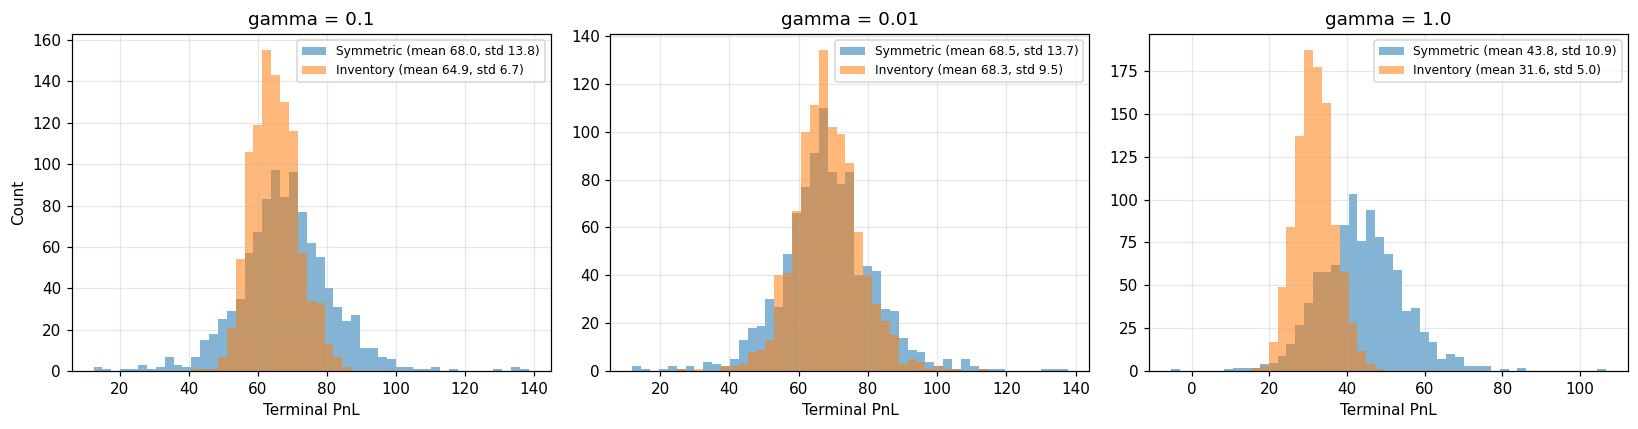

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, g in zip(axes, GAMMAS):
    inv, sym = results[(g, "inventory")].pnl, results[(g, "symmetric")].pnl
    bins = np.linspace(min(inv.min(), sym.min()), max(inv.max(), sym.max()), 50)
    ax.hist(sym, bins=bins, alpha=0.55, label=f"Symmetric (mean {sym.mean():.1f}, std {sym.std():.1f})")
    ax.hist(inv, bins=bins, alpha=0.55, label=f"Inventory (mean {inv.mean():.1f}, std {inv.std():.1f})")
    ax.set_title(f"gamma = {g}"); ax.set_xlabel("Terminal PnL"); ax.legend(fontsize=8)
axes[0].set_ylabel("Count")
plt.tight_layout(); plt.show()

### 5.2 PnL decomposition: where the money comes from, and where the risk comes from

In [8]:
dec = []
for (g, name), res in results.items():
    assert np.allclose(res.pnl, res.spread_pnl + res.inventory_pnl)
    m_inv, se_inv = mean_se(res.inventory_pnl)
    dec.append({"gamma": g, "strategy": name,
                "total mean": res.pnl.mean(), "total std": res.pnl.std(),
                "spread capture mean": res.spread_pnl.mean(), "spread capture std": res.spread_pnl.std(),
                "inventory PnL mean": m_inv, "inventory PnL SE": se_inv, "inventory PnL std": res.inventory_pnl.std(),
                "corr(spread, inv)": np.corrcoef(res.spread_pnl, res.inventory_pnl)[0, 1]})
pd.DataFrame(dec).set_index(["gamma", "strategy"]).round(2)

total mean  total std  spread capture mean  spread capture std  inventory PnL mean  inventory PnL SE  inventory PnL std  corr(spread, inv)
gamma strategy                                                                                                                                             
0.10  inventory       64.85       6.66                64.97                6.06               -0.12              0.09               2.94              -0.03
      symmetric       68.05      13.78                68.38                6.45               -0.33              0.38              12.16               0.00
0.01  inventory       68.30       9.48                68.46                6.01               -0.17              0.23               7.26               0.01
      symmetric       68.54      13.71                68.75                5.97               -0.21              0.39              12.43              -0.02
1.00  inventory       31.60       4.96                31.60                4.86                0.00              0.03               1.05              -0.01
      symmetric       43.80      10.91                43.88                7.86               -0.08              0.24               7.51               0.01

**How to read it:**

- **All of the expected profit comes from spread capture.** The mean of inventory PnL is 0 to within one or two standard errors, because the mid is a martingale and fills are independent of price moves.
- **Almost all of the difference in risk between the two strategies comes from inventory PnL.** Taking γ = 0.1 as an example: the inventory PnL of the inventory strategy fluctuates far less than that of the symmetric strategy, while the volatility of spread capture is about the same for both.
- **The money the inventory strategy gives up is in spread capture**: to flatten its position it often quotes one side closer to the mid, so each fill earns a smaller edge.

This decomposition is the baseline for the later adverse-selection experiments: once informed traders are added, the direction of fills becomes correlated with subsequent price moves, and the **mean** of inventory PnL will no longer be 0 but negative.

### 5.3 Individual fills: the distribution of edge

The trade log records each fill's direction, price, the mid at the time and the inventory before the fill. Below we look at each fill's edge relative to the mid (positive when buying below the mid or selling above it). The symmetric strategy's spread is constant, so the edge of every fill is exactly half the spread (blue dashed line); the inventory strategy's edge varies with the inventory before the fill.

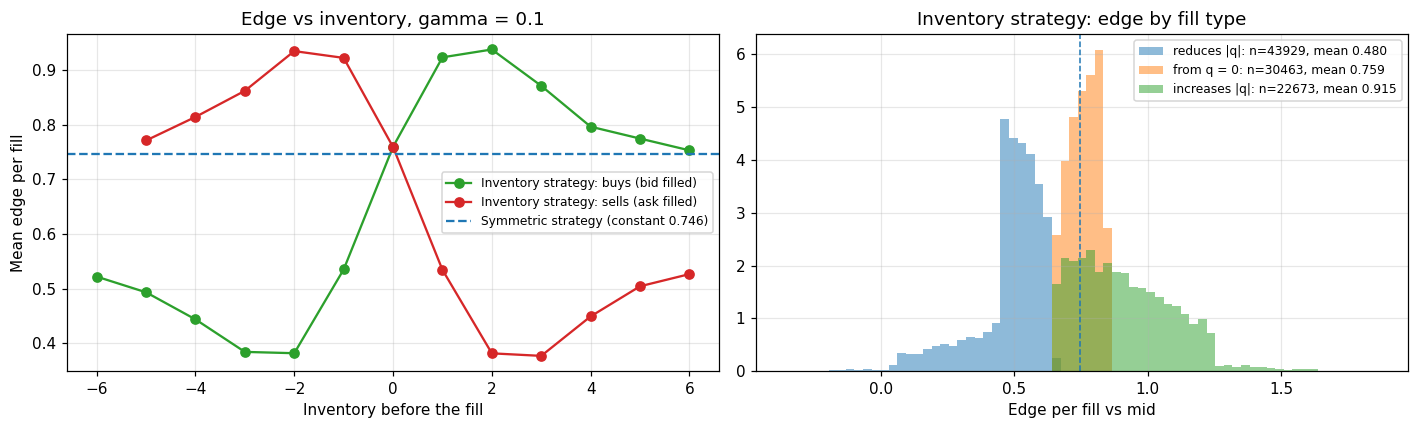

In [9]:
g = 0.1
tr = results[(g, "inventory")].trades
edge = tr["side"] * (tr["mid"] - tr["price"])   # buy below mid / sell above mid => positive
sym_edge = Symmetric.matching(g, P).spread / 2

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for side, lab, c in [(+1, "buys (bid filled)", "tab:green"), (-1, "sells (ask filled)", "tab:red")]:
    m = tr["side"] == side
    qb = tr["q_before"][m]
    levels = np.arange(-6, 7)
    means = [edge[m][qb == lv].mean() if (qb == lv).sum() > 50 else np.nan for lv in levels]
    axes[0].plot(levels, means, "o-", color=c, label=f"Inventory strategy: {lab}")
axes[0].axhline(sym_edge, color="tab:blue", ls="--", label=f"Symmetric strategy (constant {sym_edge:.3f})")
axes[0].set_xlabel("Inventory before the fill"); axes[0].set_ylabel("Mean edge per fill")
axes[0].set_title(f"Edge vs inventory, gamma = {g}"); axes[0].legend(fontsize=8)

reducing = np.sign(tr["q_before"]) == -tr["side"]     # fill moves inventory towards zero
increasing = np.sign(tr["q_before"]) == tr["side"]
flat = tr["q_before"] == 0
bins = np.linspace(edge.min(), edge.max(), 70)
for mask, lab in [(reducing, "reduces |q|"), (flat, "from q = 0"), (increasing, "increases |q|")]:
    axes[1].hist(edge[mask], bins=bins, alpha=0.5, density=True, label=f"{lab}: n={mask.sum()}, mean {edge[mask].mean():.3f}")
axes[1].axvline(sym_edge, color="tab:blue", ls="--", lw=1)
axes[1].set_xlabel("Edge per fill vs mid"); axes[1].set_title("Inventory strategy: edge by fill type"); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

Left: when holding inventory, fills in the inventory-reducing direction earn a clearly smaller edge and fills in the inventory-increasing direction a larger one, and the two lines are symmetric about q = 0. Note that the effect is strongest around |q| ≈ 2 and weakens again for larger inventory. This is a selection effect: the skew slope $\gamma\sigma^2(T-t)$ is large early on, so inventory is hard to build up; |q| reaching 5 or 6 usually happens close to T, when the skew is already weak. Right: aggregated by fill type, inventory-reducing fills earn a smaller edge on average (the strategy "is willing to earn a bit less to get rid of inventory"), and inventory-increasing fills earn a larger edge ("pay me a bit more and I will add to my position").

### 5.4 Inventory paths

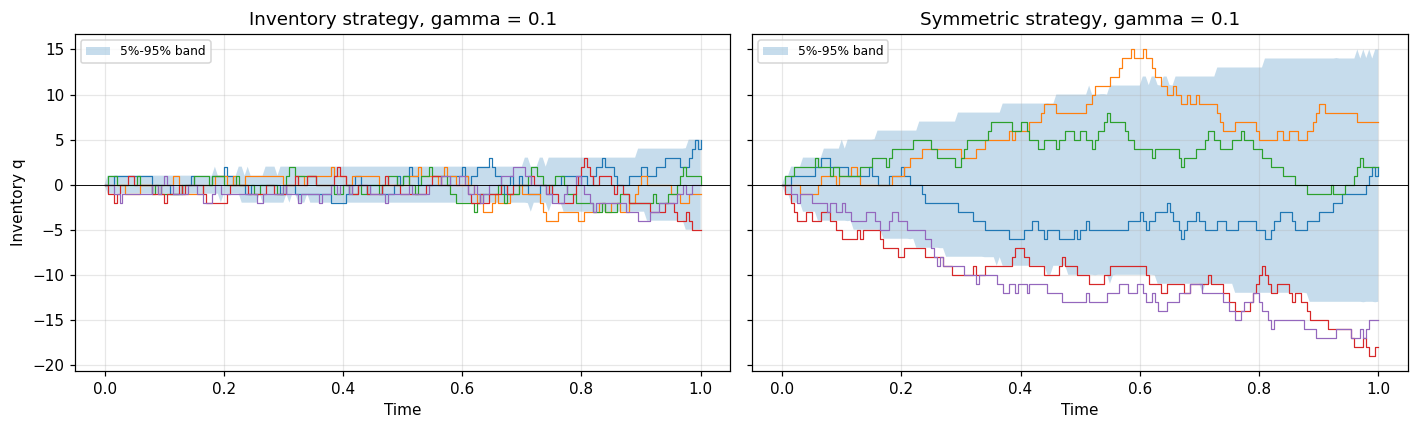

In [10]:
g = 0.1
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
rnd = draw_randomness(P, N_PATHS, SEED)
for ax, (name, strat) in zip(axes, strategies(g).items()):
    out = simulate(strat, P, N_PATHS, randomness=rnd, record=True)
    Q, t = out.paths["q"], out.t
    lo, hi = np.percentile(Q, [5, 95], axis=1)
    ax.fill_between(t, lo, hi, alpha=0.25, label="5%-95% band")
    for j in range(5):
        ax.step(t, Q[:, j], where="post", lw=0.8)
    ax.axhline(0, color="k", lw=0.6)
    ax.set_title(f"{name.capitalize()} strategy, gamma = {g}"); ax.set_xlabel("Time"); ax.legend(loc="upper left", fontsize=8)
axes[0].set_ylabel("Inventory q")
plt.tight_layout(); plt.show()

The symmetric strategy's inventory is a driftless random walk whose quantile band widens like √t; the inventory strategy's inventory is mean-reverting and its quantile band quickly stabilises.

## 6. Exact solution and validation

This section does not rely on simulation: it computes the **true values** of the statistics of this discrete model directly, and then uses them to test both the simulator and the paper.

### 6.1 Symmetric strategy: closed form

The symmetric strategy's quotes do not depend on inventory, so its moments have a closed form. Let the half-spread be $d$, the per-step fill probability on each side $\lambda = A e^{-kd}dt$, the number of steps n, and $v = 2\lambda(1-\lambda)$:

$$\mathbb{E}[\text{PnL}] = 2n\lambda d,\qquad \mathrm{Var}(q_T) = nv$$
$$\mathrm{Var}(\text{spread capture}) = 2nd^2\lambda(1-\lambda),\qquad \mathrm{Var}(\text{inventory PnL}) = \sigma^2 dt\sum_{i=0}^{n-1}\mathbb{E}[q_{i+1}^2] = \sigma^2 dt\, v\,\frac{n(n+1)}{2}$$

The two parts are uncorrelated: each $\Delta S_i$ has mean 0 and is independent of all fills.

In [11]:
chk = []
for g in GAMMAS:
    strat = Symmetric.matching(g, P)
    th = symmetric_moments(strat.spread, P)
    sim = simulate(strat, P, n_paths=40000, seed=3)
    chk.append({"gamma": g, "fill prob / step": th["fill_prob"],
                "E[PnL] closed form": th["mean_pnl"], "E[PnL] MC": sim.pnl.mean(),
                "std PnL closed form": th["std_pnl"], "std PnL MC": sim.pnl.std(),
                "std q closed form": th["std_q"], "std q MC": sim.q.std()})
pd.DataFrame(chk).set_index("gamma").round(3)

,fill prob / step,E[PnL] closed form,E[PnL] MC,std PnL closed form,std PnL MC,std q closed form,std q MC
gamma,,,,,,,
0.10,0.229,68.223,68.212,13.456,13.462,8.399,8.400
0.01,0.255,68.666,68.663,13.677,13.660,8.712,8.705
1.00,0.072,43.685,43.653,10.733,10.717,5.171,5.168


### 6.2 Any strategy: dynamic programming on the (q, t) grid

The inventory strategy's quote offsets $\delta^a, \delta^b$ depend only on (q, t), not on the price level. Define mark-to-market wealth $M_i = x_i + q_i s_i$; its one-step increment is

$$\Delta M = \underbrace{\text{sold}\cdot\delta^a + \text{bought}\cdot\delta^b}_{e} + q'\,\Delta S,\qquad q' = q - \text{sold} + \text{bought}$$

where the distribution of the fills is determined by (q, i) alone and $\Delta S$ is independent of everything else. Let $R(q,i)$ be the PnL accumulated up to T starting from step i with inventory q. Given this step's fill outcome, $R(q,i) = e + q'\Delta S + R(q', i+1)$ with the three parts mutually independent, so we can recurse backwards from T:

$$\mathbb{E}[R(q,i)^k] = \sum_{\text{4 fill outcomes}} P \sum_{j=0}^{k}\binom{k}{j}\,\mathbb{E}\big[(e + R(q',i+1))^{k-j}\big]\,q'^{\,j}\,\mathbb{E}[\Delta S^j],\quad k = 1,\dots,4$$

$$\Phi(q,i) = \mathbb{E}\big[e^{-\gamma R(q,i)}\big] = \sum P\, e^{-\gamma e}\,\cosh(\gamma q'\sigma\sqrt{dt})\,\Phi(q', i+1)$$

The terminal condition is $R(q,n) = 0$. $\mathbb{E}[R(0,0)^k]$ are the first four moments of PnL, and $-\frac1\gamma\ln\Phi(0,0)$ is the exact CARA certainty equivalent. The distribution of terminal inventory is propagated forward from $q_0 = 0$.

Because inventory changes by at most 1 per step, $|q_i| \le i \le n$, so a grid $q \in [-n, n]$ has **no truncation error at all**: this is the exact solution of the discrete model.

The implementation is in `mmsim/analytics.py::exact_moments`. It needs to be validated too, and `tests/` does two things: on a small 6-step model it enumerates all $8^6$ paths and compares the mean, standard deviation, kurtosis, CE and inventory distribution item by item, agreeing to within 1e−9 (including cases where the fill probabilities are clipped); on the symmetric strategy it compares against the closed form of 6.1, agreeing to within 1e−10. The table below puts the dynamic program side by side with a 40000-path Monte Carlo.

In [12]:
dp_rows = []
for g in GAMMAS:
    rnd = draw_randomness(P, 40000, seed=21)
    for name, strat in strategies(g).items():
        ex = EXACT[(g, name)]
        r = simulate(strat, P, 40000, randomness=rnd)
        x = r.pnl - r.pnl.mean()
        dp_rows.append({"gamma": g, "strategy": name,
                        "mean DP": ex["mean_pnl"], "mean MC": r.pnl.mean(),
                        "std DP": ex["std_pnl"], "std MC": r.pnl.std(),
                        "kurtosis DP": ex["kurt_pnl"], "kurtosis MC": np.mean(x**4) / np.mean(x**2) ** 2,
                        "std q DP": ex["std_q"], "std q MC": r.q.std(),
                        "trades DP": ex["mean_trades"], "trades MC": r.n_trades.mean(),
                        "CE DP": ex["ce"], "CE MC": cara_ce(r.pnl, g)})
pd.DataFrame(dp_rows).set_index(["gamma", "strategy"]).round(3)

mean DP  mean MC  std DP  std MC  kurtosis DP  kurtosis MC  std q DP  std q MC  trades DP  trades MC     CE DP   CE MC
gamma strategy                                                                                                                         
0.10  inventory   64.893   64.934   6.543   6.544        3.027        3.037     2.927     2.916     96.963     97.009    62.787  62.829
      symmetric   68.223   68.255  13.456  13.501        5.426        5.404     8.399     8.414     91.465     91.504    39.812  54.563
0.01  inventory   68.400   68.443   8.961   8.946        3.639        3.615     5.213     5.202    102.206    102.277    67.999  68.043
      symmetric   68.666   68.736  13.677  13.683        5.627        5.681     8.712     8.703    101.802    101.859    67.730  67.800
1.00  inventory   31.455   31.480   4.838   4.824        3.076        3.066     1.641     1.632     56.059     56.101    22.431  22.843
      symmetric   43.685   43.668  10.733  10.738        3.921        3.906     5.171     5.162     28.819     28.822 -1931.202  -9.655

Except for the last two columns, the dynamic program and Monte Carlo agree on every statistic, which shows that the simulator is implemented correctly for the inventory strategy as well.

The last two columns are far apart for the symmetric strategy: at γ = 0.1 the exact value is 39.8 while Monte Carlo gives over 50; at γ = 1 the exact value is about −1900 while Monte Carlo gives only a negative number in the single or double digits. This is not a bug: the dynamic-programming column has already been validated in the enumeration test; it is Monte Carlo that cannot estimate the value accurately, for the reasons given in 6.4.

### 6.3 Comparison with the paper

Each number in the paper is itself a 1000-path estimate and carries sampling noise. Now that we have exact values, we can compute by how many "1000-path standard errors" each of the paper's numbers deviates from the truth:

- the standard error of the mean is $\sigma/\sqrt{N}$;
- the standard error of the sample standard deviation is $\sigma\sqrt{(\kappa-1)/(4N)}$, where κ is the kurtosis (for a normal distribution κ = 3, and this reduces to the familiar $\sigma/\sqrt{2N}$).

If the paper and this implementation are the same model, these 24 z-values should be roughly standard normal.

In [13]:
ver = []
for (g, name), pp in PAPER.items():
    ex, se = EXACT[(g, name)], sampling_se(EXACT[(g, name)], N_PATHS)
    for label, key, pv in [("profit", "mean_pnl", pp[1]), ("std profit", "std_pnl", pp[2]),
                           ("final q", "mean_q", pp[3]), ("std final q", "std_q", pp[4])]:
        ver.append({"gamma": g, "strategy": name, "statistic": label, "paper": pv,
                    "exact": ex[key], "SE (1000 paths)": se[key], "z": (pv - ex[key]) / se[key]})
ver = pd.DataFrame(ver)

chi2 = float((ver.z**2).sum())
p_value = float(np.mean(np.random.default_rng(0).chisquare(len(ver), 10**6) >= chi2))
print(f"max |z| = {ver.z.abs().max():.2f},  #(|z| > 2) = {(ver.z.abs() > 2).sum()} of {len(ver)},  "
      f"chi2 = {chi2:.1f} (df = {len(ver)}),  p = {p_value:.2f}")
ver.pivot_table(index=["gamma", "strategy"], columns="statistic", values="z", sort=False).round(2)

max |z| = 1.89,  #(|z| > 2) = 0 of 24,  chi2 = 19.4 (df = 24),  p = 0.73


statistic        profit  std profit  final q  std final q
gamma strategy                                           
0.10  inventory    0.52        0.39     0.86        -0.41
      symmetric    0.42       -1.69     0.98         0.00
0.01  inventory    0.71       -1.13     0.73        -0.97
      symmetric    0.31       -1.89     0.33        -0.06
1.00  inventory   -0.36        1.47     0.39         1.61
      symmetric    0.93        0.92     0.00        -0.61

**Conclusion: the paper and this implementation agree.** All 24 z-values lie within ±1.9, and the χ² statistic is close to its expected value (24 degrees of freedom), fully consistent with "same model, differences due only to sampling noise".

A few remarks:

- The largest deviations are the PnL std of the two symmetric strategies (z ≈ −1.7, −1.9). Their kurtosis is about 5.4–5.6: the symmetric strategy's inventory is an unbounded random walk, so the variance of inventory PnL is itself random and the distribution is a "mixture of normals" with fat tails. **Computing the standard errors with the normal approximation earlier overstated these two deviations as 2.5–2.9 standard errors**, and on that basis I guessed that "the original implementation differs"; that conclusion was wrong.
- If the paper used the same random numbers for different γ, then the symmetric strategies at γ = 0.1 and 0.01 are almost the same strategy (spread 1.49 vs 1.35), so it is natural for both stds to be low together; this should not be treated as two independent coincidences.
- The paper's numbers are rounded to one decimal place, so the rounding error is up to ±0.05. For statistics with small standard errors (e.g. the std q of the inventory strategy at γ = 1, SE ≈ 0.036) this is no longer negligible, and part of the z ≈ 1.6 comes from rounding.

Below we check the "sampling noise" explanation directly by simulation: repeat an experiment of the same size as the paper's (1000 paths) 1000 times, and look at the distribution of the sample std and where the paper's number falls in it.

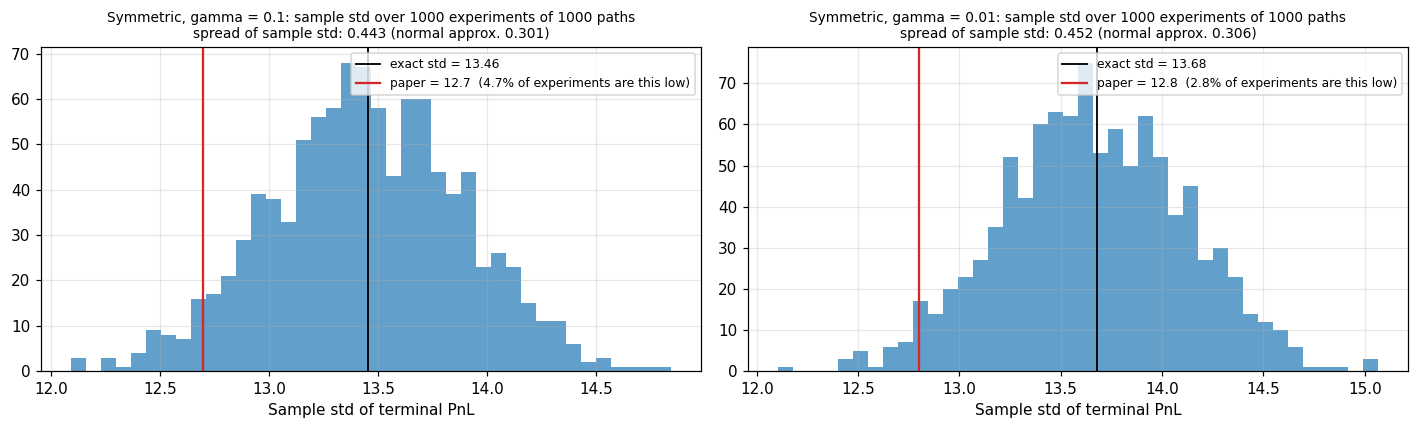

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
ce_logs = []
for ax, g in zip(axes, [0.1, 0.01]):
    strat = Symmetric.matching(g, P)
    ex, pv = EXACT[(g, "symmetric")], PAPER[(g, "symmetric")][2]
    stds = []
    for b in range(40):                                   # 40 x 25000 = 1,000,000 paths
        r = simulate(strat, P, 25000, seed=1000 + b)
        stds.append(r.pnl.reshape(25, 1000).std(axis=1, ddof=1))
        if g == 0.1:
            ce_logs.append(-g * r.pnl)
    stds = np.concatenate(stds)
    ax.hist(stds, bins=40, alpha=0.7)
    ax.axvline(ex["std_pnl"], color="k", lw=1.2, label=f"exact std = {ex['std_pnl']:.2f}")
    ax.axvline(pv, color="tab:red", lw=1.5, label=f"paper = {pv}  ({np.mean(stds <= pv):.1%} of experiments are this low)")
    ax.set_title(f"Symmetric, gamma = {g}: sample std over 1000 experiments of 1000 paths\n"
                 f"spread of sample std: {stds.std():.3f} (normal approx. {ex['std_pnl'] / np.sqrt(2 * 999):.3f})", fontsize=9)
    ax.set_xlabel("Sample std of terminal PnL"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

- Across the 1000 repeated experiments, the spread of the sample std matches the kurtosis-corrected standard error (about 0.44–0.45) and is clearly larger than the normal approximation (about 0.30).
- The paper's number sits at roughly the 3%–5% quantile of this distribution: on the low side, but entirely within what a 1000-path experiment produces.

### 6.4 Why Monte Carlo cannot estimate the CARA certainty equivalent

CARA expected utility $\mathbb{E}[e^{-\gamma\,\mathrm{PnL}}]$ weights losses **exponentially**. The symmetric strategy's inventory is an unbounded random walk; given the inventory path, inventory PnL is approximately normal with variance $\sigma^2\int q_t^2\,dt$, so

$$\mathbb{E}\big[e^{-\gamma\,\text{inventory PnL}}\big] \approx \mathbb{E}\Big[\exp\Big(\tfrac{1}{2}\gamma^2\sigma^2\int_0^T q_t^2\,dt\Big)\Big]$$

This expectation is dominated by the very few paths on which inventory drifts far away. Approximating inventory by a Brownian motion ($q_t \approx \sqrt{2L}\,W_t$, $L = Ae^{-kd}$), a classical result says that $\mathbb{E}[\exp(c\int_0^1 W_t^2\,dt)]$ is finite only when $c < \pi^2/8 \approx 1.23$. Here $c = \gamma^2\sigma^2 L$: about 0.02 at γ = 0.01, about 1.8 at γ = 0.1, and about 58 at γ = 1. In other words, in the continuous-time limit the expected utility of the symmetric strategy is −∞ at γ = 0.1 and γ = 1; in the discrete model it is finite, but determined by paths of vanishingly small probability.

Monte Carlo almost never samples these paths, so it systematically overestimates the CE, and adding paths makes it converge extremely slowly. The demonstration below uses the same batch of 1 million paths (γ = 0.1):

In [15]:
z = np.concatenate(ce_logs)
ce_rows = []
for n_ in [10**3, 10**4, 10**5, 10**6]:
    zz = z[:n_]; m = zz.max()
    ce_rows.append({"paths": n_, "CE (Monte Carlo)": -(m + np.log(np.mean(np.exp(zz - m)))) / 0.1})
ce_rows.append({"paths": "exact (DP)", "CE (Monte Carlo)": EXACT[(0.1, "symmetric")]["ce"]})
pd.DataFrame(ce_rows).set_index("paths").round(2)

,CE (Monte Carlo)
paths,
1000,53.99
10000,48.08
100000,44.48
1000000,49.17
exact (DP),39.81


This is precisely why the A-S strategy exists: judged by the market maker's own objective, a strategy that ignores inventory is far riskier than mean–variance suggests. The inventory strategy's inventory is mean-reverting and has no such tail, so its CE can be estimated accurately by Monte Carlo too (see the table in 6.2).

**Practical lesson:** when reporting CARA utility, either use an exact method, or report only a second-order approximation such as mean − γ/2·Var and state that it is an approximation; do not simply compute $-\frac1\gamma\ln\overline{e^{-\gamma X}}$ on Monte Carlo samples.

## 7. Discretisation diagnostics

The paper itself notes that choosing dt is subtle: dt must be small enough that several orders are unlikely to arrive within one step, but it cannot be smaller than the real tick time. Here we quantify the effect of dt = 0.005.

### 7.1 How often probabilities are clipped and both sides fill

In [16]:
diag = []
for (g, name), res in results.items():
    diag.append({"gamma": g, "strategy": name,
                 "clipped (prob > 1)": res.clip_frac, "both sides filled in one step": res.both_fill_frac,
                 "mean fills / step / side": res.n_trades.mean() / (2 * P.n_steps)})
pd.DataFrame(diag).set_index(["gamma", "strategy"]).round(4)

clipped (prob > 1)  both sides filled in one step  mean fills / step / side
gamma strategy                                                                              
0.10  inventory              0.0001                         0.0530                    0.2427
      symmetric              0.0000                         0.0528                    0.2292
0.01  inventory              0.0000                         0.0650                    0.2557
      symmetric              0.0000                         0.0651                    0.2548
1.00  inventory              0.0260                         0.0174                    0.1406
      symmetric              0.0000                         0.0054                    0.0724

- Clipping is noticeable only for the inventory strategy at γ = 1: with large γ the skew $q\gamma\sigma^2(T-t)$ is large, so the quote on one side easily crosses the mid.
- At γ = 0.01 and 0.1 the per-step fill probability on each side is about 0.23–0.26, and both sides fill in the same step in about 5%–6% of steps. This no longer counts as "dt small enough": the error of approximating Poisson by Bernoulli is not negligible; see the next section.

### 7.2 Convergence in dt

Keep T, A and k fixed and change only dt. The symmetric strategy can be compared directly with the closed form, including the continuous-time limit dt → 0 (where fills become Poisson):

$$\mathrm{Var}(q_T) \to 2LT,\qquad \mathrm{Var}(\text{PnL}) \to 2LTd^2 + \sigma^2 L T^2,\qquad L = Ae^{-kd}$$

Every variance term of the discrete model carries an extra factor $(1-\lambda)$, so **at finite dt it understates risk**.

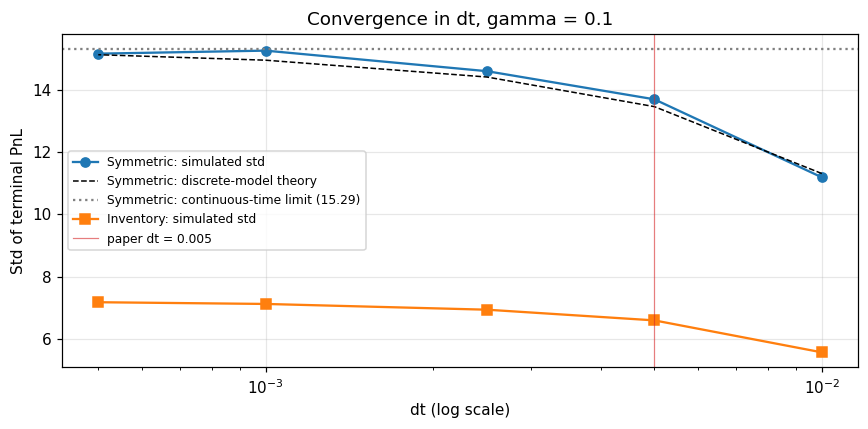

,inventory mean,inventory std,symmetric mean,symmetric std,symmetric std theory
dt,,,,,
0.0100,65.69,5.57,68.42,11.19,11.31
0.0050,64.87,6.60,68.15,13.69,13.46
0.0025,64.50,6.94,68.51,14.59,14.41
0.0010,64.26,7.13,68.26,15.25,14.95
0.0005,64.09,7.18,68.39,15.16,15.12


In [17]:
dts = [0.01, 0.005, 0.0025, 0.001, 0.0005]
g = 0.1
conv = []
for dt in dts:
    p = P.with_(dt=dt)
    rnd = draw_randomness(p, 10000, seed=1)
    row = {"dt": dt}
    for name, strat in strategies(g, p).items():
        r = simulate(strat, p, 10000, randomness=rnd)
        row[f"{name} mean"], row[f"{name} std"] = r.pnl.mean(), r.pnl.std()
    row["symmetric std theory"] = symmetric_moments(Symmetric.matching(g, p).spread, p)["std_pnl"]
    conv.append(row)
conv = pd.DataFrame(conv).set_index("dt")
cont = symmetric_moments_continuous(Symmetric.matching(g, P.with_(dt=1e-5)).spread, P)

fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogx(conv.index, conv["symmetric std"], "o-", label="Symmetric: simulated std")
ax.semilogx(conv.index, conv["symmetric std theory"], "k--", lw=1, label="Symmetric: discrete-model theory")
ax.axhline(cont["std_pnl"], color="grey", ls=":", label=f"Symmetric: continuous-time limit ({cont['std_pnl']:.2f})")
ax.semilogx(conv.index, conv["inventory std"], "s-", label="Inventory: simulated std")
ax.axvline(0.005, color="tab:red", lw=0.8, alpha=0.6, label="paper dt = 0.005")
ax.set_xlabel("dt (log scale)"); ax.set_ylabel("Std of terminal PnL"); ax.set_title(f"Convergence in dt, gamma = {g}")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()
conv.round(2)

- The PnL **mean** of both strategies is not very sensitive to dt.
- The **standard deviation** clearly depends on dt: at the paper's dt = 0.005 the symmetric strategy's PnL standard deviation is about 12% below the continuous-time limit. The inventory strategy's standard deviation also rises, but by less, because its inventory is kept under control and its inventory risk is small to begin with.
- So the conclusion that "A-S halves the standard deviation" holds across dt, but the exact numbers are a function of dt. Reported results should state dt, or use a sufficiently small dt.

## 8. Summary and limitations

**Replication findings:**
1. The exact dynamic-programming solution shows that all 24 numbers in the paper's Tables 1–3 agree with this implementation to within 1000-path sampling noise (max |z| ≈ 1.9). The simulator itself also agrees with the exact solution, the closed form and brute-force enumeration.
2. The earlier finding that "the symmetric strategy's std deviates from the paper by 2.5 standard errors" was caused by the normal approximation understating the standard error; the symmetric strategy's PnL kurtosis is about 5.4.
3. The core trade-off: at the same spread, skewing quotes by inventory gives up a little mean (about 3 at γ = 0.1, with the 95% CI given above) in exchange for halving the PnL standard deviation and cutting the standard deviation of terminal inventory to about one third. γ controls how much is traded.
4. All of the expected profit comes from spread capture; inventory PnL has mean 0 and contributes only risk.
5. By A-S's own objective (CARA utility), the symmetric strategy is much worse than mean–variance suggests: at γ = 0.1 its exact CE is 39.8, versus 62.8 for A-S. This quantity cannot be estimated by Monte Carlo.

**Model limitations (which are also directions for extension):**
- Fills are independent of price moves: there is no adverse selection. This is exactly why inventory PnL has mean 0.
- Per-step Bernoulli fills approximate Poisson fills, with a visible bias already at dt = 0.005.
- The fill intensity depends only on the distance: there is no queue position, tick size or latency; every fill is for 1 share, with no fees or rebates.
- Inventory is unbounded; terminal inventory is liquidated at the mid at no cost.
- The quoting formula is a first-order asymptotic approximation in q, not the exact solution of the HJB equation. Guéant, Lehalle & Fernandez-Tapia (2013) give the exact solution with bounded inventory.

---
## Appendix: derivations

### A.1 Indifference prices with frozen inventory

Consider an agent who does not trade and just holds q shares until T. Since $S_T \sim N(s, \sigma^2(T-t))$, the exponential utility can be computed directly:

$$v(x,s,q,t) = -e^{-\gamma x}\, e^{-\gamma q s}\, e^{\frac{1}{2}\gamma^2 q^2 \sigma^2 (T-t)}$$

The **reservation bid** $r^b$ is defined by $v(x - r^b, s, q+1, t) = v(x,s,q,t)$: paying $r^b$ for one more share leaves the agent indifferent. The reservation ask is defined in the same way. Solving gives

$$r^a = s + (1-2q)\frac{\gamma\sigma^2(T-t)}{2},\qquad r^b = s + (-1-2q)\frac{\gamma\sigma^2(T-t)}{2}$$

Their average is the reservation price $r = s - q\gamma\sigma^2(T-t)$. It is the marginal risk cost of one more share: when long, you value the stock below the mid, and the offset shrinks as T approaches.

### A.2 HJB and optimal distances

Once limit orders are allowed, the value function $u(s,x,q,t) = \max \mathbb{E}_t[-e^{-\gamma(X_T+q_TS_T)}]$ satisfies an HJB equation: a diffusion term $\frac12\sigma^2u_{ss}$, plus jump terms on the bid and ask sides that occur with intensity λ. The ansatz $u = -e^{-\gamma x}e^{-\gamma\theta(s,q,t)}$ eliminates x. The first-order optimality conditions give implicit equations for the optimal distances; for exponential λ, the inventory-independent part is $\frac{1}{\gamma}\ln(1+\frac{\gamma}{k})$.

### A.3 Asymptotic expansion in q

Expand θ as $\theta = \theta^0 + q\theta^1 + \frac12 q^2\theta^2 + \dots$ and linearise the fill terms. Collecting terms by order in q gives two linear PDEs, whose solutions are $\theta^1 = s$ and $\theta^2 = -\sigma^2\gamma(T-t)$, so that

$$\delta^a + \delta^b = \gamma\sigma^2(T-t) + \frac{2}{\gamma}\ln\left(1+\frac{\gamma}{k}\right)$$

with the quotes placed symmetrically around r. The two terms of the spread are:
- $\gamma\sigma^2(T-t)$: compensation for inventory risk, decaying linearly to 0;
- $\frac{2}{\gamma}\ln(1+\gamma/k)$: the liquidity term. As γ → 0 it tends to $2/k$, exactly twice the value that maximises $\delta e^{-k\delta}$ under risk neutrality, $\delta = 1/k$.

### A.4 Where λ(δ) comes from

Market orders arrive at a constant total rate Λ, order sizes have density $f(x)\propto x^{-1-\alpha}$, and the price impact is $\Delta p = \frac1K\ln Q$. A limit order at distance δ is filled if and only if the impact exceeds δ:

$$\lambda(\delta) = \Lambda\,P(\Delta p > \delta) = \Lambda\,P(Q > e^{K\delta}) = A e^{-k\delta},\quad A = \Lambda/\alpha,\ k = \alpha K.$$

---
## Appendix B: why the preprint's tables do not match

With the exact solution in hand, we can test directly whether the 2006 preprint's Tables 1–3 could have been produced by any reasonable implementation. The preprint's description is ambiguous in two places: whether the symmetric strategy's spread is $\frac{2}{\gamma}\ln(1+\frac{\gamma}{k})$ or the time average, and whether the inventory strategy's spread includes the $\gamma\sigma^2(T-t)$ term. Below we compute exact values for all four combinations, and then see by how many 1000-path standard errors the preprint's numbers deviate.

In [18]:
from dataclasses import dataclass

@dataclass(frozen=True)
class SkewConstantSpread:
    # A-S reservation price, but only the constant liquidity term of the spread
    gamma: float
    name: str = "skew + constant spread"
    def quote(self, s, q, i, p):
        r = s - q * self.gamma * p.sigma**2 * p.tau(i)
        half = np.log1p(self.gamma / p.k) / self.gamma
        return r, r - half, r + half

# Preprint (2006) Tables 1-3: profit, std(profit), final q, std(final q)
PREPRINT = {
    (0.1,  "inventory"): (62.94,  5.89,  0.10,  2.80), (0.1,  "symmetric"): (67.21, 13.43, -0.018, 8.66),
    (0.01, "inventory"): (66.78,  8.76, -0.02,  4.70), (0.01, "symmetric"): (67.36, 13.40, -0.31,  8.65),
    (0.5,  "inventory"): (33.92,  4.72, -0.02,  1.88), (0.5,  "symmetric"): (66.20, 14.53,  0.25,  9.06),
}
candidates = {
    "inventory": {"full A-S spread": AvellanedaStoikov, "constant spread": SkewConstantSpread},
    "symmetric": {"time-averaged spread": lambda g: Symmetric.matching(g, P),
                  "constant ln-term spread": lambda g: Symmetric(2 / g * np.log1p(g / P.k))},
}
pre_rows = []
for (g, name), pp in PREPRINT.items():
    for label, make in candidates[name].items():
        ex = exact_moments(make(g), P)
        se = sampling_se(ex, 1000)
        zs = [(pv - ex[k]) / se[k] for k, pv in zip(["mean_pnl", "std_pnl", "mean_q", "std_q"], pp)]
        pre_rows.append({"gamma": g, "strategy": name, "interpretation": label,
                         "profit (preprint)": pp[0], "profit (exact)": ex["mean_pnl"],
                         "z profit": zs[0], "z std": zs[1], "z final q": zs[2], "z std q": zs[3],
                         "max |z|": max(abs(z) for z in zs)})
pd.DataFrame(pre_rows).set_index(["gamma", "strategy", "interpretation"]).round(2)

profit (preprint)  profit (exact)  z profit  z std  z final q  z std q  max |z|
gamma strategy  interpretation                                                                                          
0.10  inventory full A-S spread                      62.94           64.89     -9.44  -4.43       1.08    -1.94     9.44
                constant spread                      62.94           64.22     -6.69  -1.16       1.08    -1.93     6.69
      symmetric time-averaged spread                 67.21           68.22     -2.38  -0.06      -0.07     1.39     2.38
                constant ln-term spread              67.21           68.64     -3.27  -0.71      -0.06    -0.89     3.27
0.01  inventory full A-S spread                      66.78           68.40     -5.72  -0.87      -0.12    -4.40     5.72
                constant spread                      66.78           68.40     -5.73  -0.70      -0.12    -4.40     5.73
      symmetric time-averaged spread                 67.36           68.67     -3.02  -0.60      -1.13    -0.32     3.02
                constant ln-term spread              67.36           68.67     -3.02  -0.66      -1.12    -0.54     3.02
0.50  inventory full A-S spread                      33.92           48.57    -78.54  -8.87      -0.32    -1.74    78.54
                constant spread                      33.92           23.90     62.51  -3.06      -0.32    -1.69    62.51
      symmetric time-averaged spread                 66.20           59.92     16.12   5.97       1.14    13.82    16.12
                constant ln-term spread              66.20           67.96     -4.00   1.17       0.87    -0.31     4.00

- For γ = 0.1 and 0.01, in every row and under every interpretation, the preprint's mean PnL is 1.0–2.0 below the exact value, with z between −2.4 and −9.4.
- γ = 0.5 is even clearer: the inventory strategy deviates by −79 and +63 standard errors under the two interpretations (the preprint's 33.92 falls between them); the symmetric strategy deviates by +16 and −4 standard errors under the two interpretations.
- No interpretation makes the preprint's tables consistent with the model it describes. The preprint's experiment code was probably different from the final model; the authors re-ran the experiments for the published version and switched to the average spread as the benchmark, and the published numbers agree fully with this implementation (Section 6.3).
- A replication should therefore follow the published version, and anyone citing "the paper's tables" should say which version they mean.